In [1]:
import pandas as pd
df=pd.read_csv("Gold Price.csv")
df.head()
df.isnull().sum()

Date      0
Price     0
Open      0
High      0
Low       0
Volume    0
Chg%      0
dtype: int64

In [2]:
(df['High'] < df['Low']).sum()

np.int64(0)


=== Summary Comparison ===
             Abs_Chg  Daily_Volatility        Volume
Day_Type                                            
Holiday     0.509574        471.121951  12376.951220
Normal Day  0.605271        519.064316  14888.331701


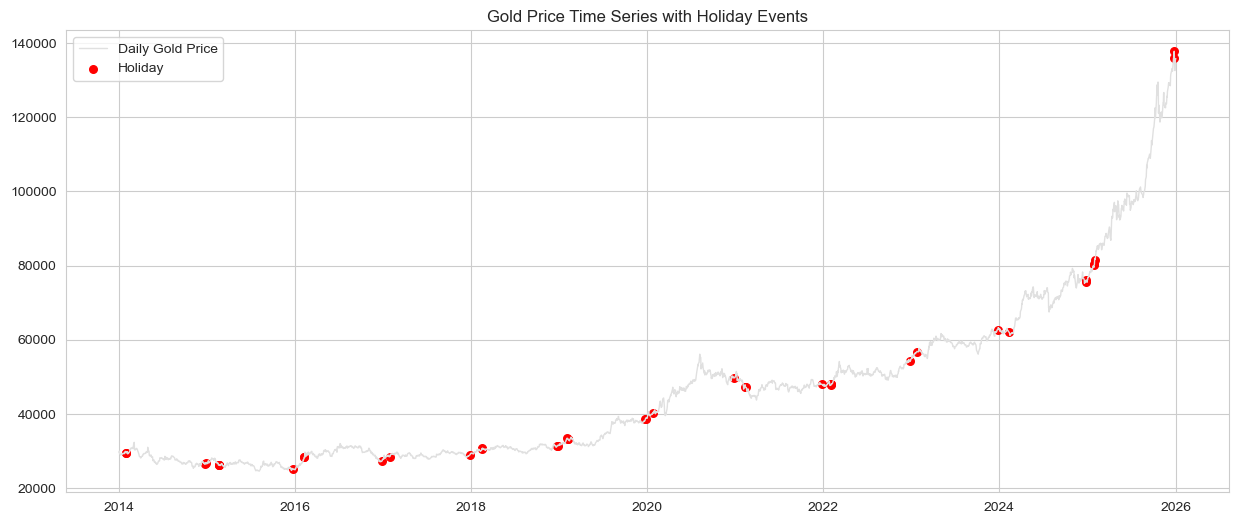

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True)

try:
    df = pd.read_csv('Gold Price.csv')
    df['Date'] = pd.to_datetime(df['Date'])
except FileNotFoundError:
    print("Error: 'Gold Price.csv' not found.")

df = df.sort_values('Date')

holiday_dates = [
    '2014-01-31','2015-02-19','2016-02-08','2017-01-28',
    '2018-02-16','2019-02-05','2020-01-25','2021-02-12',
    '2022-02-01','2023-01-22','2024-02-10','2025-01-29','2026-02-17',
    '2014-12-25','2015-12-25','2016-12-25','2017-12-25',
    '2018-12-25','2019-12-25','2020-12-25','2021-12-25',
    '2022-12-25','2023-12-25','2024-12-25','2025-12-25','2026-12-25'
]

holiday_dates = pd.to_datetime(holiday_dates)

df['Is_Holiday'] = df['Date'].apply(
    lambda x: any(abs((x - d).days) <= 1 for d in holiday_dates)
)

df['Day_Type'] = df['Is_Holiday'].map({
    True: 'Holiday',
    False: 'Normal Day'
})

df['Abs_Chg'] = df['Price'].pct_change().abs() * 100

df['Daily_Volatility'] = df['High'] - df['Low']

summary = df.groupby('Day_Type').agg({
    'Abs_Chg': 'mean',
    'Daily_Volatility': 'mean',
    'Volume': 'mean'
})

print("\n=== Summary Comparison ===")
print(summary)

sns.set_style("whitegrid")

plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Price'], color='#E0E0E0', linewidth=1, label='Daily Gold Price')

holidays = df[df['Is_Holiday']]
plt.scatter(holidays['Date'], holidays['Price'], color='red', s=30, label='Holiday')

plt.title('Gold Price Time Series with Holiday Events')
plt.legend()
plt.savefig("Gold Price Time Series with Holiday Events.png")
plt.show()

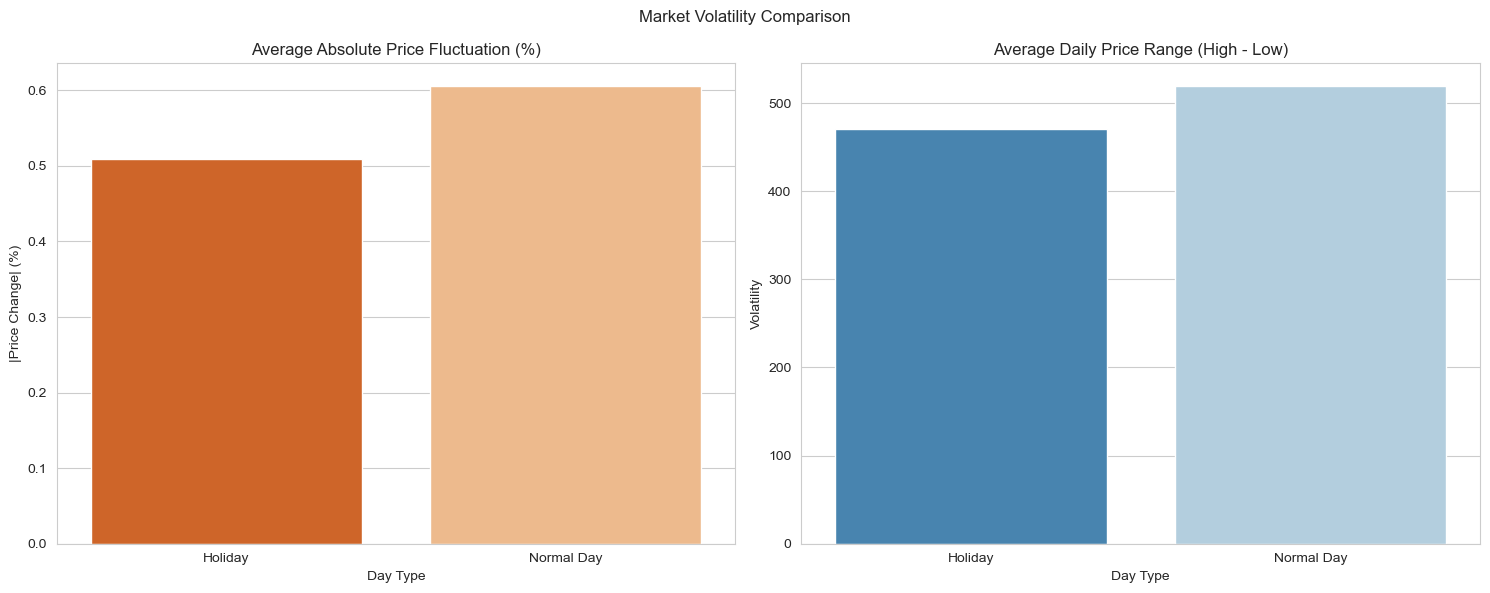

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

order = ['Holiday', 'Normal Day']

sns.barplot(
    data=df,
    x='Day_Type',
    y='Abs_Chg',
    hue='Day_Type',
    palette='Oranges',
    order=order,
    ax=ax1,
    errorbar=None,
    legend=False
)

ax1.set_title('Average Absolute Price Fluctuation (%)')
ax1.set_ylabel('|Price Change| (%)')
ax1.set_xlabel('Day Type')

sns.barplot(
    data=df,
    x='Day_Type',
    y='Daily_Volatility',
    hue='Day_Type',
    palette='Blues',
    order=order,
    ax=ax2,
    errorbar=None,
    legend=False
)

ax2.set_title('Average Daily Price Range (High - Low)')
ax2.set_ylabel('Volatility')
ax2.set_xlabel('Day Type')

plt.suptitle('Market Volatility Comparison')
plt.tight_layout()
plt.savefig("Market Volatility Comparison.png")
plt.show()

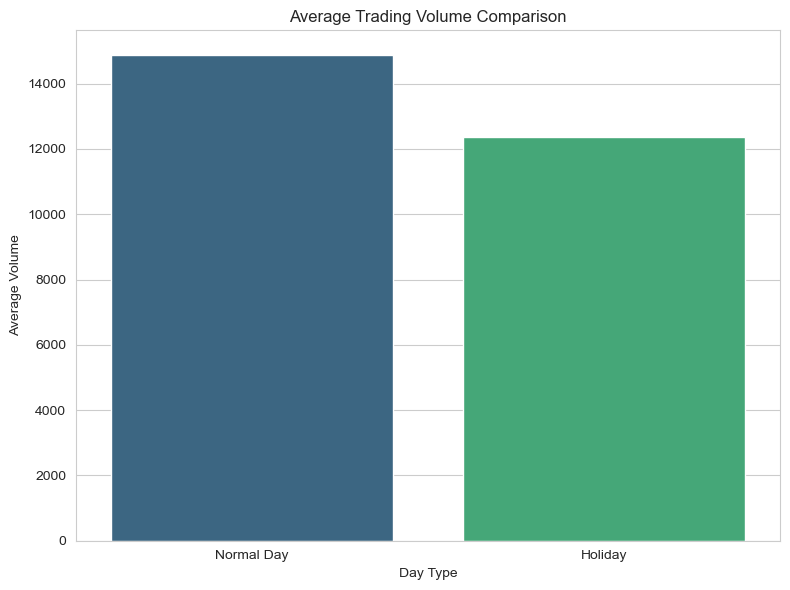

In [3]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=df,
    x='Day_Type',
    y='Volume',
    hue='Day_Type',
    palette='viridis',
    errorbar=None,
    legend=False
)

plt.title('Average Trading Volume Comparison')
plt.ylabel('Average Volume')
plt.xlabel('Day Type')
plt.tight_layout()
plt.savefig("Average Trading Volume Comparison.png")
plt.show()

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
df = pd.read_csv("Gold Price.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'] = df['Price'].ffill()
scaler = MinMaxScaler()
df['Price_Normalized'] = scaler.fit_transform(df[['Price']])
df['Price_Log'] = np.log(df['Price'])
df.head()

,Date,Price,Open,High,Low,Volume,Chg%,Price_Normalized,Price_Log
3103,2014-01-01,29542,29435,29598,29340,2930,0.25,0.044126,10.293568
3102,2014-01-02,29975,29678,30050,29678,3140,1.47,0.047950,10.308119
3101,2014-01-03,29727,30031,30125,29539,3050,-0.83,0.045760,10.299811
3100,2014-01-04,29279,29279,29279,29279,0,-1.51,0.041804,10.284626
3099,2014-01-06,29119,29300,29395,29051,24380,-0.55,0.040391,10.279146
